In [131]:
%load_ext autoreload
%autoreload 2

# XLA_PYTHON_CLIENT_PREALLOCATE = False
import jax
import jax.numpy as jnp
import equinox as eqx

import numpy as np
import matplotlib.pyplot as plt

from qdots_qll.distributions import Distribution, update_particles_locations, update_weights

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

from jax import jit
from jax.scipy.linalg import expm

from qdots_qll.models.single_dot_weak_coupling_GAME import *

from qdots_qll.resamplers import LWResampler

resampler = LWResampler(a=0.95)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def det_fim(model, *args, **kwargs):
    return jnp.linalg.det(model.fim(*args, **kwargs))


def choose_given_p(key, discrete_distribution):
    outcomes = jnp.arange(discrete_distribution.shape[0])
    return jax.random.choice(key, outcomes, p=discrete_distribution)



In [3]:
no_particles = 100
no_rv = 4

print(true_parameters)
seed = 1
key = jax.random.PRNGKey(seed)
key, subkey = jax.random.split(key)

model = SingleDotWeakCouplingGAME()

no_initial_states = 4
no_measurement_basis = 3
dist_initial_state = jnp.ones(no_initial_states) / no_initial_states
dist_measurement_basis = jnp.ones(no_measurement_basis) / no_measurement_basis

initial_covariance = jnp.diagflat(jnp.ones(4) * 0.05) ** 2
particles_locations = jax.random.multivariate_normal(subkey,
                                                     mean=true_parameters,
                                                     cov=initial_covariance,
                                                     shape=(no_particles,))

weights = jnp.ones(no_particles) / no_particles

distribution = Distribution(particles_locations, weights)
# 
# key, subkey = jax.random.split(key)
# particles = jax.random.normal(subkey, (no_particles, no_rv))
# 
# key, subkey = jax.random.split(key)
# new_particles = jax.random.normal(subkey, (no_particles, no_rv))

[ 0.3142169   0.35833007  0.05385149 -0.33369482]


In [4]:
jnp.log10(jnp.abs(true_parameters))

Array([-0.5027704 , -0.4457167 , -1.2688023 , -0.47665054], dtype=float32)

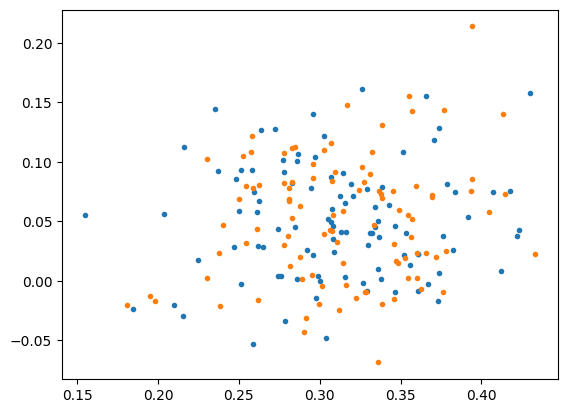

In [5]:
i, j = 0, 2

plt.plot(distribution.particles_locations[:, i], distribution.particles_locations[:, j], '.')

key, new_weights, new_particles_locations = resampler.resample(key, distribution.particles_locations,
                                                               distribution.weights).values()

new_distribution = update_particles_locations(distribution, new_particles_locations)
new_distribution = update_weights(new_distribution, new_weights)

plt.plot(new_distribution.particles_locations[:, i], new_distribution.particles_locations[:, j], '.')



In [6]:
distribution.ev()

Array([ 0.31070176,  0.35328418,  0.05019309, -0.3335423 ], dtype=float32)

In [7]:
distribution.check_resampling()

Array(False, dtype=bool)

In [8]:
model.fim?

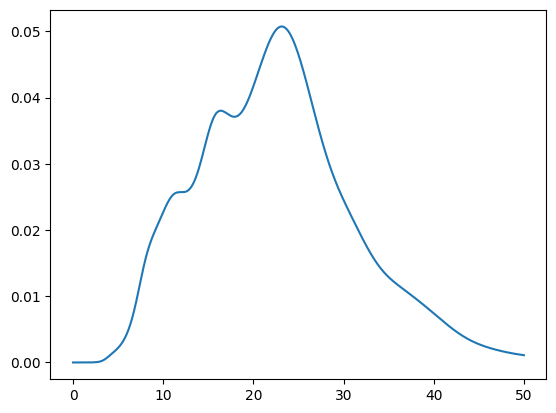

In [9]:
times = jnp.linspace(0, 50, 1000)

det_fim_times = jax.vmap(lambda t: det_fim(model, particle=true_parameters, t=t, prob_initial_state=dist_initial_state,
                                           prob_measurement_basis=dist_measurement_basis))(
    times)

plt.plot(times, det_fim_times)

In [10]:
key, subkey = jax.random.split(key)
choose_given_p(subkey, dist_initial_state)

Array(1, dtype=int32)

In [11]:
key, new_weights, new_particles_locations = resampler.resample(key, distribution.particles_locations,
                                                               distribution.weights).values()

distribution = update_particles_locations(distribution, new_particles_locations)
distribution = update_weights(distribution, new_weights)

In [12]:
distribution.ev()

Array([ 0.3148062 ,  0.3542175 ,  0.05037577, -0.33108044], dtype=float32)

In [13]:
jax.random.truncated_normal?

In [14]:
from tensorflow_probability.substrates import jax as tfp

In [15]:
tfp.distributions.TruncatedNormal?

In [16]:
boundaries = jnp.array([
    [0.01, 0.9],
    [0.01, 0.9],
    [0.001, 0.22],
    [-0.9, -0.01],
])

In [17]:
boundaries

Array([[ 0.01 ,  0.9  ],
       [ 0.01 ,  0.9  ],
       [ 0.001,  0.22 ],
       [-0.9  , -0.01 ]], dtype=float32)

In [18]:
mus = boundaries.mean(axis=1)
sigmas = jnp.abs((boundaries[:, 0] - boundaries[:, 1]) / (2 * 4))

In [19]:
key, subkey = jax.random.split(key)
tfp.distributions.TruncatedNormal(loc=mus, scale=sigmas, low=boundaries[:, 0], high=boundaries[:, 1]).sample(
    seed=subkey, sample_shape=5)

Array([[ 0.2542469 ,  0.41595924,  0.14057353, -0.39855036],
       [ 0.46032718,  0.35709184,  0.0812095 , -0.4999085 ],
       [ 0.44812205,  0.5014723 ,  0.10704919, -0.407346  ],
       [ 0.5736978 ,  0.5013548 ,  0.13920361, -0.5165159 ],
       [ 0.35466498,  0.39085436,  0.13067372, -0.5124587 ]],      dtype=float32)

In [20]:
boundaries[:, 1]

Array([ 0.9 ,  0.9 ,  0.22, -0.01], dtype=float32)

In [21]:
boundaries[:, 0]

Array([ 0.01 ,  0.01 ,  0.001, -0.9  ], dtype=float32)

In [22]:
jnp.diag(sigmas)

Array([[0.11125 , 0.      , 0.      , 0.      ],
       [0.      , 0.11125 , 0.      , 0.      ],
       [0.      , 0.      , 0.027375, 0.      ],
       [0.      , 0.      , 0.      , 0.11125 ]], dtype=float32)

In [23]:
jnp.linalg.cholesky(distribution.cov()).T

Array([[0.05538603, 0.00943651, 0.0092432 , 0.00374923],
       [0.        , 0.04546412, 0.00623   , 0.00881934],
       [0.        , 0.        , 0.0480373 , 0.01346091],
       [0.        , 0.        , 0.        , 0.04261059]], dtype=float32)

In [24]:
boundaries

Array([[ 0.01 ,  0.9  ],
       [ 0.01 ,  0.9  ],
       [ 0.001,  0.22 ],
       [-0.9  , -0.01 ]], dtype=float32)

In [25]:
good_particle = true_parameters
bad_particle = jnp.array([0.1, 0.2, -0.1, -0.7])

test_pars = jnp.array([good_particle, bad_particle])

In [496]:
# def is_valid_particle(particle, boundaries):
#     return ((boundaries[:, 1] > particle) * (boundaries[:, 0] <= particle)).T.prod(axis=0)

def is_valid_particle(particle, boundaries):
    return jnp.bool(
        ((boundaries[:, 1] > particle) * (boundaries[:, 0] <= particle)).T.prod(axis=0)
    )[0]

In [61]:
is_probability_correct = lambda p: jnp.logical_and((p >= 0.0), (p <= 1.0))

trim_invalid_probs = lambda prob_array: jnp.where(is_probability_correct(prob_array), prob_array,
                                                  jnp.abs(prob_array) * 0)

trim_nan_probs = lambda prob_array: jnp.where(~jnp.isnan(prob_array), prob_array, jnp.abs(prob_array) * 0)


def clean_probabilities(prob_array):
    return trim_nan_probs(trim_invalid_probs(prob_array))

In [114]:
test_pars

Array([[ 0.3142169 ,  0.35833007,  0.05385149, -0.33369482],
       [ 0.1       ,  0.2       , -0.1       , -0.7       ]],      dtype=float32)

In [540]:
from qdots_qll.resamplers import LWResamplerBounds

re = LWResamplerBounds(parameters_bounds=boundaries)
f = re.resample_one_particle
nukey, cand, iter = f(nukey, distribution.particles_locations, distribution.weights, distribution.ev(),
                      50 * distribution.cov())

print(cand)
print(iter)

TypeError: cond_fun must return a boolean scalar, but got output type(s) [ShapedArray(bool[1])].

In [455]:
cand.shape

(1, 4)

In [324]:
re.cond_keep_resampling(cand, iter)

Array(True, dtype=bool)

In [153]:
re.parameters_bounds

Array([[ 0.01 ,  0.9  ],
       [ 0.01 ,  0.9  ],
       [ 0.001,  0.22 ],
       [-0.9  , -0.01 ]], dtype=float32)

In [178]:
jnp.bool(is_valid_particle(
    re.propose_new_particle(subkey, distribution.particles_locations, distribution.weights, distribution.ev(),
                            distribution.cov())[1], boundaries))

Array([ True], dtype=bool)

In [138]:
test_pars = jnp.array([good_particle, bad_particle, bad_particle, good_particle + 0.001])

In [140]:
(test_pars, boundaries)

Array([1, 0, 0, 1], dtype=int32)

In [141]:
test_pars

Array([[ 0.3142169 ,  0.35833007,  0.05385149, -0.33369482],
       [ 0.1       ,  0.2       , -0.1       , -0.7       ],
       [ 0.1       ,  0.2       , -0.1       , -0.7       ],
       [ 0.3152169 ,  0.35933006,  0.05485149, -0.33269483]],      dtype=float32)

In [142]:
from jax.experimental import checkify

In [547]:

check_bnds(test_pars[0], boundaries).shape

(1,)

In [156]:
?jax.lax.while_loop

In [388]:
key, subkey = jax.random.split(key)

subkeys = jax.random.split(subkey, no_particles)

In [471]:
subkeys

Array([[ 527159774, 3114478750],
       [3318116435, 3677801735],
       [3756009942, 2510100502],
       [ 510570685, 3994738022],
       [3396352110, 2584771356],
       [ 580170816, 3825174913],
       [3281951803, 2078535679],
       [2598045903,   25016194],
       [3378804931, 2144316706],
       [3716160112,  691172776],
       [3476617721, 4238848228],
       [2963550800, 2623601879],
       [4272066815, 1482831193],
       [2195402675, 3839235182],
       [ 921547284, 3441680137],
       [1343957670,  794871824],
       [3226185037, 2169615214],
       [2865236044, 2201544075],
       [1305817832, 3537227162],
       [ 151604343,  898848232],
       [1756499319, 3435730104],
       [1783320145, 3592594460],
       [1904680482, 2518134237],
       [1863631982, 3010672640],
       [3322015652, 3385264368],
       [2594802979, 1441770827],
       [ 328635057, 1794907083],
       [  78431716, 1309096935],
       [3055420353, 3325505544],
       [1910155597, 1213176635],
       [29

In [476]:
nu_pars = jax.vmap(lambda key: re.propose_new_particle(key, particles_locations, weights, distribution.ev(), distribution.cov()))(
    subkeys)

In [484]:
nu_pars[1][3]

Array([[ 0.27261928,  0.32267892,  0.10716745, -0.31468087]], dtype=float32)

In [483]:
nu_pars[1].reshape([no_particles, no_rv])[3]

Array([ 0.27261928,  0.32267892,  0.10716745, -0.31468087], dtype=float32)

In [505]:
re.resample_one_particle(key, particles_locations, weights, distribution.ev(), distribution.cov())[1].shape

(4,)

In [559]:
from qdots_qll.resamplers import LWResamplerBounds, is_valid_particle_array_version, is_valid_particle

re = LWResamplerBounds(parameters_bounds=boundaries)

nu_pars = re.resample(subkey, distribution.particles_locations, distribution.weights)[1]

In [586]:
from qdots_qll.resamplers import LWResamplerBounds, is_valid_particle_array_version, is_valid_particle

re = LWResamplerBounds(parameters_bounds=boundaries)

nu_pars_dos = re.resample(subkey, distribution.particles_locations, distribution.weights)[1]

In [588]:
is_valid_particle_array_version(nu_pars, boundaries)

Array([ True, False,  True,  True, False, False, False,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
       False,  True,  True, False,  True,  True,  True, False,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
       False], dtype=bool)

In [587]:
is_valid_particle_array_version(nu_pars_dos, boundaries)

Array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True], dtype=bool)

In [590]:
nu_pars_dos[0]

Array([ 0.28674126,  0.37098813,  0.08213624, -0.34783012], dtype=float32)

In [593]:
(nu_pars == nu_pars_dos).prod(axis=1)

Array([1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0], dtype=int32)

In [558]:
is_valid_particle(jnp.atleast_2d(true_parameters), boundaries)

Array(True, dtype=bool)

In [533]:
jnp.atleast_2d(true_parameters)

Array([[ 0.3142169 ,  0.35833007,  0.05385149, -0.33369482]], dtype=float32)

In [530]:
test_pars[None, :]

Array([[[ 0.3142169 ,  0.35833007,  0.05385149, -0.33369482],
        [ 0.1       ,  0.2       , -0.1       , -0.7       ],
        [ 0.1       ,  0.2       , -0.1       , -0.7       ],
        [ 0.3152169 ,  0.35933006,  0.05485149, -0.33269483]]],      dtype=float32)

In [528]:
test_pars.ndim == 1

False

In [ ]:
key, subkey = jax.random.split(key)

wrong_ones = 
subkeys = jax.random.split(subkey, wrong_ones)

def resample_wrong_one(particle, subkey):
    
    true_fun = lambda particle, subkey: particle
    def false_fun(particle, subkey):
        _, candidate, _ = re.resample_one_particle(subkey, particles_locations, weights, mu, sigma)
        return candidate
    
    
    return jax.lax.cond(is_valid_particle(particle, boundaries), true_fun, false_fun, *(particle, subkey))

jax.vmap(resample_wrong_one, in_axes=(0, 0))()

In [578]:
(~jax.vmap(lambda par: is_valid_particle(par, boundaries))(nu_pars)).flatten().sum()

Array(20, dtype=int32)